In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import importlib
import auxiliares

from pathlib import Path
from stereodemo.method_cre_stereo import CREStereo
from stereodemo.method_opencv_bm import StereoBM, StereoSGBM
from stereodemo.methods import InputPair, Config

## Calibración

In [39]:
# Carpeta de la CÁTEDra
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_board/calib"

def first_match(patterns):
    for p in patterns:
        m = sorted(glob.glob(os.path.join(base_dir, p)))
        if m:
            return m
    raise FileNotFoundError(f"No encontré archivos con patrones: {patterns} en {base_dir}")

def one_file(patterns):
    files = first_match(patterns)
    return files[0]

# Patrones habituales (ajustá si tu set tiene otro naming)
LEFT_PATTERNS  = ["left*.jpg", "left*.png", "L*.jpg", "L*.png", "*_left*.jpg", "*_left*.png"]
RIGHT_PATTERNS = ["right*.jpg", "right*.png", "R*.jpg", "R*.png", "*_right*.jpg", "*_right*.png"]

In [40]:
# =========================================================
# 1. Parámetros del tablero checkerboard
# =========================================================
checkerboard = (10, 7)          # número de esquinas internas (puntos por fila, puntos por columna)
square_size_mm = 24.2           # tamaño del cuadrado en milímetros
square_size = square_size_mm / 1000.0  # convertir a metros (opcional, para coherencia 3D)


# =========================================================
# 2. Función para obtener puntos 3D del patrón
# =========================================================
def generar_puntos_objeto(checkerboard, square_size):
    """
    Genera las coordenadas 3D del patrón del checkerboard en el plano Z=0.
    """
    objp = np.zeros((checkerboard[0] * checkerboard[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard[0], 0:checkerboard[1]].T.reshape(-1, 2)
    objp *= square_size
    return objp


# =========================================================
# 3. Calibración estéreo
# =========================================================
def calibrar_stereo_checkerboard(base_dir, checkerboard, square_size):

    left_images = sorted(glob.glob(os.path.join(base_dir, "calib_left*.jpg")))
    right_images = sorted(glob.glob(os.path.join(base_dir, "calib_right*.jpg")))

    assert len(left_images) == len(right_images) and len(left_images) > 0, \
        "Debe haber el mismo número de imágenes left/right y al menos una pareja."

    # Criterio de terminación para cornerSubPix
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # Preparar puntos 3D del tablero
    objp = generar_puntos_objeto(checkerboard, square_size)

    objpoints = []   # puntos 3D reales en el mundo
    imgpointsL = []  # puntos 2D detectados en la cámara izquierda
    imgpointsR = []  # puntos 2D detectados en la cámara derecha

    print(f"Detectando checkerboard en {len(left_images)} pares de imágenes...")

    for left_path, right_path in zip(left_images, right_images):
        imgL = cv2.imread(left_path)
        imgR = cv2.imread(right_path)
        grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
        grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

        # Detectar esquinas del tablero
        retL, cornersL = cv2.findChessboardCorners(grayL, checkerboard, None)
        retR, cornersR = cv2.findChessboardCorners(grayR, checkerboard, None)

        if retL and retR:
            objpoints.append(objp)

            # Refinar las esquinas
            cornersL = cv2.cornerSubPix(grayL, cornersL, (11, 11), (-1, -1), criteria)
            cornersR = cv2.cornerSubPix(grayR, cornersR, (11, 11), (-1, -1), criteria)

            imgpointsL.append(cornersL)
            imgpointsR.append(cornersR)

    print(f"Se detectaron {len(objpoints)} pares válidos de imágenes para calibrar.")

    # Calibrar cámaras individuales
    retL, K1, d1, _, _ = cv2.calibrateCamera(objpoints, imgpointsL, grayL.shape[::-1], None, None)
    retR, K2, d2, _, _ = cv2.calibrateCamera(objpoints, imgpointsR, grayR.shape[::-1], None, None)

    # Calibración estéreo
    flags = cv2.CALIB_FIX_INTRINSIC
    criteria_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5)

    retS, K1, d1, K2, d2, R, T, E, F = cv2.stereoCalibrate(
        objpoints, imgpointsL, imgpointsR,
        K1, d1, K2, d2,
        grayL.shape[::-1],
        criteria=criteria_stereo,
        flags=flags
    )

    # Guardar resultados
    calib = {
        "left_K": K1, "left_dist": d1,
        "right_K": K2, "right_dist": d2,
        "R": R, "T": T, "E": E, "F": F
    }

    os.makedirs(base_dir, exist_ok=True)
    with open(os.path.join(base_dir, "stereo_calibration.pkl"), "wb") as f:
        pickle.dump(calib, f)

    print("\n✅ Calibración estéreo guardada en stereo_calibration.pkl")
    return calib

base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_board/calib"
calib = calibrar_stereo_checkerboard(base_dir, checkerboard, square_size)


Detectando checkerboard en 28 pares de imágenes...
Se detectaron 28 pares válidos de imágenes para calibrar.

✅ Calibración estéreo guardada en stereo_calibration.pkl


In [41]:
# Cargar (o inferir) calibración
calib_file = os.path.join(base_dir, "stereo_calibration.pkl")
if not os.path.exists(calib_file):
    raise FileNotFoundError(
        f"No se encontró {calib_file}.\n"
        f"Generá la calibración en esta carpeta o ajustá 'base_dir' al lugar correcto."
    )

with open(calib_file, "rb") as f:
    calib = pickle.load(f)

def np_print(name, arr):
    np.set_printoptions(precision=4, suppress=True)
    print(f"\n{name} =\n{arr}")

print("### PARÁMETROS DE CALIBRACIÓN ESTÉREO (CÁTEDRA) ###")
np_print("K1", calib["left_K"])
np_print("d1", calib["left_dist"])
np_print("K2", calib["right_K"])
np_print("d2", calib["right_dist"])
np_print("R",  calib["R"])
np_print("T",  calib["T"])
np_print("E",  calib["E"])
np_print("F",  calib["F"])

left_K, left_dist  = calib["left_K"],  calib["left_dist"]
right_K, right_dist= calib["right_K"], calib["right_dist"]
R, T               = calib["R"], calib["T"]

# Tamaño de imagen
if "image_size" in calib:
    image_size = tuple(calib["image_size"])
else:
    sample_img = cv2.imread(one_file(LEFT_PATTERNS))
    image_size = (sample_img.shape[1], sample_img.shape[0])  # (w,h)
    print("⚠️ 'image_size' no estaba en el pickle, se infirió como:", image_size)


### PARÁMETROS DE CALIBRACIÓN ESTÉREO (CÁTEDRA) ###

K1 =
[[600.9208   0.     963.9213]
 [  0.     600.6995 550.5259]
 [  0.       0.       1.    ]]

d1 =
[[ 0.005  -0.0233 -0.0002  0.0016  0.0036]]

K2 =
[[596.967    0.     957.9515]
 [  0.     598.2916 532.5189]
 [  0.       0.       1.    ]]

d2 =
[[ 0.     -0.0215 -0.0005 -0.0007  0.0033]]

R =
[[ 0.9999 -0.0006  0.0143]
 [ 0.0005  0.9999  0.013 ]
 [-0.0143 -0.013   0.9998]]

T =
[[-0.0591]
 [ 0.002 ]
 [-0.003 ]]

E =
[[-0.      0.0029  0.002 ]
 [-0.0038 -0.0008  0.059 ]
 [-0.002  -0.0591 -0.0008]]

F =
[[ 0.     -0.      0.001 ]
 [ 0.      0.     -0.108 ]
 [-0.0023  0.1031  1.    ]]
⚠️ 'image_size' no estaba en el pickle, se infirió como: (1920, 1080)


## Rectificación

⚠️ 'image_size' no estaba en el pickle, se infirió como: (1920, 1080)
✅ Mapas de rectificación guardados en: tp2_reconstruccion_3d/datasets/stereo_budha_board/calib/stereo_maps.pkl


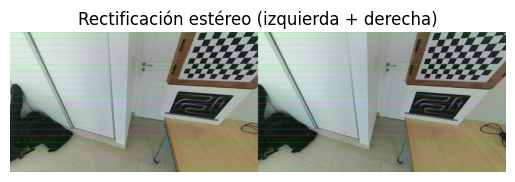

In [42]:
# =========================================================
# 1. Rutas y carga de calibración
# =========================================================
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_board/calib"
calib_file = os.path.join(base_dir, "stereo_calibration.pkl")

with open(calib_file, "rb") as f:
    calib = pickle.load(f)

# =========================================================
# 2. Extraer los parámetros
# =========================================================
left_K = calib["left_K"]
left_dist = calib["left_dist"]
right_K = calib["right_K"]
right_dist = calib["right_dist"]
R = calib["R"]
T = calib["T"]

# Inferir tamaño de imagen si no está guardado
if "image_size" in calib:
    image_size = tuple(calib["image_size"])
else:
    # Busca una imagen cualquiera con 'left' en el nombre
    sample_path = sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0]
    sample_img = cv2.imread(sample_path)
    image_size = (sample_img.shape[1], sample_img.shape[0])  # (w, h)
    print("⚠️ 'image_size' no estaba en el pickle, se infirió como:", image_size)

# =========================================================
# 3. Calcular la rectificación estéreo
# =========================================================
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist,
    right_K, right_dist,
    image_size,
    R, T,
    alpha=0,           # 0: recorte máximo, 1: sin recorte
    newImageSize=image_size
)

# =========================================================
# 4. Generar los mapas de rectificación
# =========================================================
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1
)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1
)

# =========================================================
# 5. Guardar los mapas
# =========================================================
stereo_maps = {
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,
    "image_size": image_size
}

maps_file = os.path.join(base_dir, "stereo_maps.pkl")
with open(maps_file, "wb") as f:
    pickle.dump(stereo_maps, f)

print("✅ Mapas de rectificación guardados en:", maps_file)

# =========================================================
# 6. (Opcional) Visualización de prueba
# =========================================================
# Para verificar que la rectificación quedó alineada correctamente:
left_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0])
right_img = cv2.imread(sorted(glob.glob(os.path.join(base_dir, "*right*.jpg")))[0])

left_rect = cv2.remap(left_img, left_map_x, left_map_y, cv2.INTER_LINEAR)
right_rect = cv2.remap(right_img, right_map_x, right_map_y, cv2.INTER_LINEAR)

# Dibujar líneas horizontales para verificar la alineación epipolar
vis = np.hstack((left_rect, right_rect))
for y in range(0, vis.shape[0], 50):
    cv2.line(vis, (0, y), (vis.shape[1], y), (0, 255, 0), 1)

plt.imshow(vis[:, :, ::-1])  # Convertir BGR a RGB para matplotlib
plt.axis("off")
plt.title("Rectificación estéreo (izquierda + derecha)")
plt.show()


In [43]:
# === Rectificar en batch las CAPTURAS del Buddha y guardar ROI color ===
import os, glob, re, cv2, pickle
import numpy as np

# 1) Cargar mapas/ROIs desde la calibración (ya los generaste)
with open(os.path.join(base_dir, "stereo_maps.pkl"), "rb") as f:
    maps = pickle.load(f)
left_map_x  = maps["left_map_x"];  left_map_y  = maps["left_map_y"]
right_map_x = maps["right_map_x"]; right_map_y = maps["right_map_y"]
validRoi1   = maps["validRoi1"];   validRoi2   = maps["validRoi2"]

# 2) Rutas de entrada/salida
captures_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_board/captures"   # crudas del Buddha
out_roi      = os.path.join(captures_dir, "rectificadas")                       # ROI color para stereodemo
os.makedirs(out_roi, exist_ok=True)

# 3) Emparejar archivos L/R de manera flexible
all_imgs = sorted(glob.glob(os.path.join(captures_dir, "*.jpg")) +
                  glob.glob(os.path.join(captures_dir, "*.png")))

def parse_side_and_key(fname):
    name = os.path.basename(fname).lower()
    if "left" in name or re.search(r"(^|[_\-])l([_\-]|\d|\.|$)", name):
        side = "L"
    elif "right" in name or re.search(r"(^|[_\-])r([_\-]|\d|\.|$)", name):
        side = "R"
    else:
        side = None
    m = re.search(r"(\d+)", name)
    key = m.group(1) if m else name
    return side, key

L_dict, R_dict = {}, {}
for f in all_imgs:
    side, key = parse_side_and_key(f)
    if side == "L": L_dict.setdefault(key, f)
    if side == "R": R_dict.setdefault(key, f)

keys = sorted(set(L_dict) & set(R_dict))
assert keys, f"No se pudieron emparejar capturas en {captures_dir}. Revisá nombres L/R."

# 4) Intersección de ROIs (común a todos los pares)
x1,y1,w1,h1 = validRoi1
x2,y2,w2,h2 = validRoi2
xI, yI = max(x1,x2), max(y1,y2)
xA, yA = min(x1+w1, x2+w2), min(y1+h1, y2+h2)
assert xI < xA and yI < yA, "Las ROIs no se intersectan; revisá calibración."
wI, hI = xA - xI, yA - yI

# 5) Rectificar cada par y guardar ROI **color**
for i, k in enumerate(keys, 1):
    lp, rp = L_dict[k], R_dict[k]
    Lc = cv2.imread(lp, cv2.IMREAD_COLOR)
    Rc = cv2.imread(rp, cv2.IMREAD_COLOR)
    if Lc is None or Rc is None:
        print("❌ Error leyendo:", lp, "o", rp); continue

    # remap (color)
    Lr = cv2.remap(Lc, left_map_x,  left_map_y,  cv2.INTER_LINEAR)
    Rr = cv2.remap(Rc, right_map_x, right_map_y, cv2.INTER_LINEAR)

    # recorte ROI común
    Lr_roi = Lr[yI:yI+hI, xI:xI+wI]
    Rr_roi = Rr[yI:yI+hI, xI:xI+wI]

    # guardar con naming para stereodemo
    cv2.imwrite(os.path.join(out_roi, f"rect_left_color_{i:04d}.png"),  Lr_roi)
    cv2.imwrite(os.path.join(out_roi, f"rect_right_color_{i:04d}.png"), Rr_roi)

print(f"✅ Rectificación del Buddha lista en: {out_roi}")


✅ Rectificación del Buddha lista en: tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas


### Visualización Lineas Epipolares

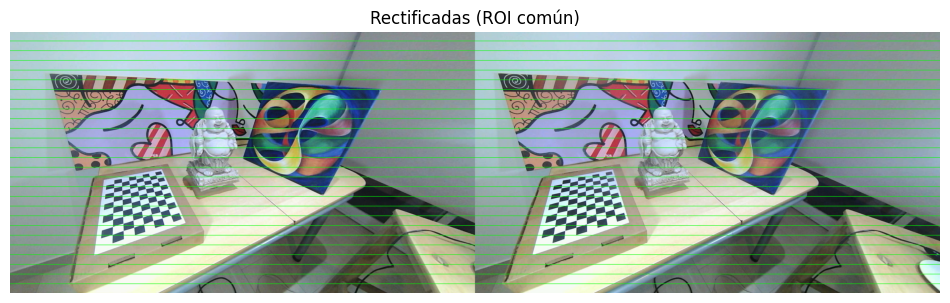

In [44]:
def visualizar_rectificadas(left_rect, right_rect, step=50, title="Rectificadas"):
    # Aseguro RGB para plt (si vienen BGR)
    if left_rect.ndim == 3 and left_rect.shape[2] == 3:
        L = cv2.cvtColor(left_rect, cv2.COLOR_BGR2RGB)
        R = cv2.cvtColor(right_rect, cv2.COLOR_BGR2RGB)
    else:
        L = left_rect
        R = right_rect

    vis = np.hstack((L, R))
    vis_lines = vis.copy()
    for y in range(0, vis.shape[0], step):
        if vis_lines.ndim == 3:
            vis_lines[y:y+2, :, :] = (0, 255, 0)
        else:
            vis_lines[y:y+2, :] = 255  # si es gris, línea blanca

    plt.figure(figsize=(12,5))
    plt.imshow(vis_lines, cmap=None if vis_lines.ndim==3 else "gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


Lp = cv2.imread(os.path.join(out_roi, "rect_left_color_0001.png"))
Rp = cv2.imread(os.path.join(out_roi, "rect_right_color_0001.png"))
visualizar_rectificadas(Lp, Rp, step=40, title="Rectificadas (ROI común)")


## Stereodemo

✅ Listo: guardados disp_raw_*.npy y disp_color_*.png en tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas


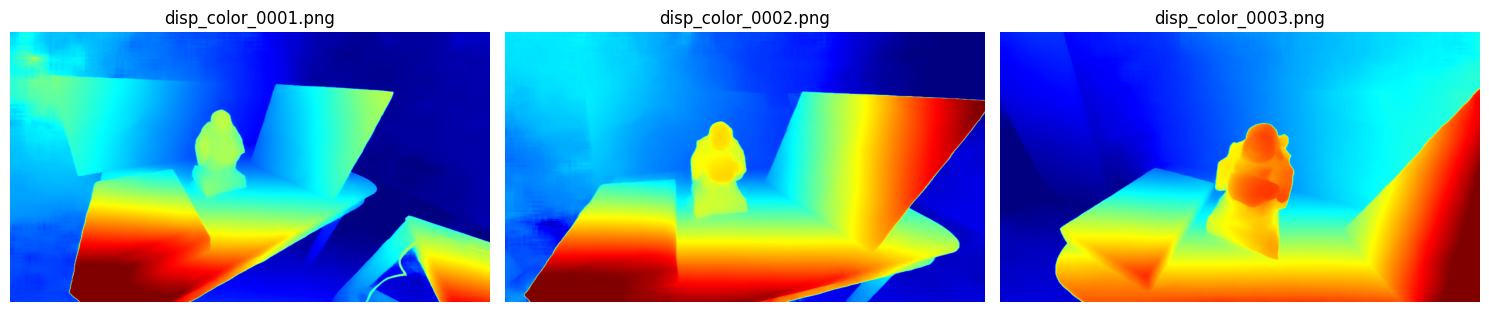

In [45]:
import os, glob, cv2, numpy as np
from pathlib import Path
from stereodemo.method_cre_stereo import CREStereo
from stereodemo.method_opencv_bm import StereoBM, StereoSGBM
from stereodemo.methods import InputPair, Config

path_imgs = "tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas"  # ROI color
models_dir = Path.home() / ".cache" / "stereodemo" / "models"
cfg = Config(models_path=models_dir)
metodo = "cre"  # o "sgbm"/"bm"

method = {"cre": CREStereo, "bm": StereoBM, "sgbm": StereoSGBM}[metodo](cfg)

lefts  = sorted(glob.glob(os.path.join(path_imgs, "rect_left_color_*.png")))
rights = sorted(glob.glob(os.path.join(path_imgs, "rect_right_color_*.png")))
assert len(lefts)==len(rights) and len(lefts)>0, f"No hay pares en {path_imgs}"

for lp, rp in zip(lefts, rights):
    L = cv2.imread(lp, cv2.IMREAD_COLOR)
    R = cv2.imread(rp, cv2.IMREAD_COLOR)
    pair = InputPair(left_image=L, right_image=R, calibration=None, status=os.path.basename(lp))
    disp = method.compute_disparity(pair).disparity_pixels.astype(np.float32)

    # guardo crudo .npy
    base = os.path.basename(lp).replace("rect_left_color_", "").rsplit(".",1)[0]
    np.save(os.path.join(path_imgs, f"disp_raw_{base}.npy"), disp)

    # visualización opcional
    p2, p98 = np.nanpercentile(disp, [2, 98])
    dvis = (255*np.clip((disp - p2)/(p98 - p2 + 1e-6), 0, 1)).astype(np.uint8)
    dcol = cv2.applyColorMap(dvis, cv2.COLORMAP_JET)
    cv2.imwrite(os.path.join(path_imgs, f"disp_color_{base}.png"), dcol)

print("✅ Listo: guardados disp_raw_*.npy y disp_color_*.png en", path_imgs)

# === 5) Mostrar 3 ejemplos ===
disp_imgs = sorted(glob.glob(os.path.join(path_imgs, "disp_color_*.png")))
n = min(3, len(disp_imgs))
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]
for ax, p in zip(axes, disp_imgs[:n]):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(os.path.basename(p)); ax.axis("off")
plt.tight_layout(); plt.show()


## Recontrucción 3D

In [54]:
import cv2
import numpy as np
import open3d as o3d
import glob
import os
import pickle

# =========================================================
# CONFIGURACIÓN
# =========================================================
path_imgs = "tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas"
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_board/calib"

# Parámetros del checkerboard (MISMO que usaste en calibración)
checkerboard = (10, 7)
square_size = 24.2 / 1000.0  # metros

# Parámetros de filtrado
FILTRAR_DISTANCIA = True
MAX_DISTANCE = 0.8
FILTRAR_LIMITES_XY = True
X_MIN, X_MAX = -0.3, 0.3
Y_MIN, Y_MAX = -0.3, 0.3
FILTRAR_ESTADISTICO = True
STAT_NB_NEIGHBORS = 30
STAT_STD_RATIO = 1.5
VOXEL_DOWNSAMPLE = 0.002

# =========================================================
# 1. CARGAR CALIBRACIÓN Y MAPAS
# =========================================================
with open(os.path.join(base_dir, "stereo_calibration.pkl"), "rb") as f:
    calib = pickle.load(f)

with open(os.path.join(base_dir, "stereo_maps.pkl"), "rb") as f:
    maps = pickle.load(f)

K1 = np.asarray(calib["left_K"], dtype=np.float64)
K2 = np.asarray(calib["right_K"], dtype=np.float64)
d1 = np.asarray(calib["left_dist"], dtype=np.float64)
d2 = np.asarray(calib["right_dist"], dtype=np.float64)
R_mat = calib["R"]
T_vec = calib["T"].reshape(3, 1)

Q = maps["Q"]
P1 = maps["P1"]  # Matriz de proyección rectificada
P2 = maps["P2"]
R1 = maps["R1"]  # Rotación de rectificación
R2 = maps["R2"]
validRoi1 = maps["validRoi1"]
validRoi2 = maps["validRoi2"]

# Extraer matriz intrínseca rectificada de P1 (3x3)
K1_rect = P1[:3, :3]

# Calcular offset ROI
x1, y1, w1, h1 = validRoi1
x2, y2, w2, h2 = validRoi2
xI, yI = max(x1, x2), max(y1, y2)

# Ajustar Q por el recorte ROI
Q_adjusted = Q.copy()
Q_adjusted[0, 3] -= float(xI)
Q_adjusted[1, 3] -= float(yI)

print("✅ Calibración cargada")
print(f"   K1 original shape: {K1.shape}")
print(f"   K1 rectificada (de P1): {K1_rect.shape}")
print(f"   Q ajustada con offset: ({xI}, {yI})")

# =========================================================
# 2. FUNCIÓN: Generar puntos 3D del checkerboard
# =========================================================
def generar_puntos_objeto(checkerboard, square_size):
    """Genera coordenadas 3D del patrón en el plano Z=0"""
    objp = np.zeros((checkerboard[0] * checkerboard[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard[0], 0:checkerboard[1]].T.reshape(-1, 2)
    objp *= square_size
    return objp

# =========================================================
# 3. FUNCIÓN: Crear nube desde disparidad con filtrado
# =========================================================
def crear_nube_desde_disparity(disp, img_rgb, Q):
    """Crea nube de puntos con filtrado básico"""
    # Reproyectar a 3D
    points_3d = cv2.reprojectImageTo3D(disp, Q)
    
    # Máscara de filtrado
    mask = np.ones(disp.shape, dtype=bool)
    
    # Filtro 1: Disparidad válida
    mask &= np.isfinite(disp) & (disp > 0)
    
    # Filtro 2: Valores finitos en 3D
    mask &= np.isfinite(points_3d[:, :, 0])
    mask &= np.isfinite(points_3d[:, :, 1])
    mask &= np.isfinite(points_3d[:, :, 2])
    
    # Filtro 3: Distancia máxima
    if FILTRAR_DISTANCIA:
        distances = np.linalg.norm(points_3d, axis=2)
        mask &= (distances < MAX_DISTANCE) & (distances > 0.05)
        mask &= (points_3d[:, :, 2] > 0.05) & (points_3d[:, :, 2] < MAX_DISTANCE)
    
    # Filtro 4: Límites en X e Y
    if FILTRAR_LIMITES_XY:
        x_valid = (points_3d[:, :, 0] > X_MIN) & (points_3d[:, :, 0] < X_MAX)
        y_valid = (points_3d[:, :, 1] > Y_MIN) & (points_3d[:, :, 1] < Y_MAX)
        mask &= x_valid & y_valid
    
    # Extraer puntos válidos
    pts = points_3d[mask]
    cols = img_rgb[mask]
    
    if len(pts) == 0:
        return o3d.geometry.PointCloud()
    
    # Crear nube Open3D
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
    pcd.colors = o3d.utility.Vector3dVector(cols.astype(np.float64) / 255.0)
    
    return pcd

# =========================================================
# 4. PROCESAMIENTO MULTI-VISTA
# =========================================================
print(f"\n{'='*60}")
print("PROCESANDO MÚLTIPLES VISTAS")
print(f"{'='*60}")

# Listar todos los pares
left_imgs = sorted(glob.glob(os.path.join(path_imgs, "rect_left_color_*.png")))
disp_paths = sorted(glob.glob(os.path.join(path_imgs, "disp_raw_*.npy")))

assert len(left_imgs) == len(disp_paths), "Mismatch entre imágenes y disparidades"
print(f"Encontradas {len(left_imgs)} vistas")

# Generar puntos 3D del checkerboard (sistema del objeto/mundo)
objp = generar_puntos_objeto(checkerboard, square_size)

nubes_transformadas = []
poses_camara = []

for i, (left_path, disp_path) in enumerate(zip(left_imgs, disp_paths), 1):
    print(f"\n--- Vista {i}/{len(left_imgs)} ---")
    print(f"   Procesando: {os.path.basename(left_path)}")
    
    # Cargar imagen y disparidad
    left_img_bgr = cv2.imread(left_path)
    left_img_gray = cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2GRAY)
    left_img_rgb = cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2RGB)
    disp = np.load(disp_path).astype(np.float32)
    
    # 1. Detectar checkerboard en imagen rectificada
    ret, corners = cv2.findChessboardCorners(left_img_gray, checkerboard, None)
    
    if not ret:
        print(f"   ⚠️  No se detectó checkerboard, saltando...")
        continue
    
    # Refinar esquinas
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners = cv2.cornerSubPix(left_img_gray, corners, (11, 11), (-1, -1), criteria)
    
    # 2. Calcular pose: objeto → cámara
    # IMPORTANTE: Usar K1_rect porque las imágenes están rectificadas
    # y distCoeffs=None porque ya no tienen distorsión
    ret, rvec, tvec = cv2.solvePnP(
        objp,           # Puntos 3D en sistema del objeto
        corners,        # Puntos 2D en la imagen RECTIFICADA
        K1_rect,        # Matriz intrínseca RECTIFICADA
        None,           # SIN distorsión (imagen ya rectificada)
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    
    print(f"   ✅ Checkerboard detectado")
    print(f"      rvec: {rvec.flatten()}")
    print(f"      tvec: {tvec.flatten()}")
    print(f"      Distancia al tablero: {np.linalg.norm(tvec):.3f}m")
    
    # 3. Construir matriz homogénea 4x4: c_T_o (objeto → cámara)
    c_R_o, _ = cv2.Rodrigues(rvec)
    c_T_o = np.column_stack((c_R_o, tvec))  # [R|t] 3x4
    c_T_o = np.vstack((c_T_o, [0, 0, 0, 1]))  # Hacer 4x4
    
    # 4. INVERTIR para obtener o_T_c (cámara → objeto/mundo)
    o_T_c = np.linalg.inv(c_T_o)
    
    poses_camara.append(o_T_c)
    
    # 5. Crear nube en sistema de coordenadas de la cámara
    pcd_local = crear_nube_desde_disparity(disp, left_img_rgb, Q_adjusted)
    
    if len(pcd_local.points) == 0:
        print(f"   ⚠️  No se generaron puntos válidos")
        continue
    
    print(f"   📊 Puntos generados: {len(pcd_local.points)}")
    
    # 6. Transformar puntos de cámara → mundo (objeto)
    pcd_world = pcd_local.transform(o_T_c)
    
    nubes_transformadas.append(pcd_world)

print(f"\n{'='*60}")
print(f"✅ Procesadas {len(nubes_transformadas)} vistas con éxito")
print(f"{'='*60}")

# =========================================================
# 5. FUSIÓN DE NUBES
# =========================================================
if len(nubes_transformadas) == 0:
    print("❌ No se generaron nubes de puntos")
    exit(1)

print(f"\nFUSIONANDO NUBES...")

# Unir todas las nubes
nube_completa = nubes_transformadas[0]
for pcd in nubes_transformadas[1:]:
    nube_completa += pcd

print(f"✅ Nube fusionada: {len(nube_completa.points)} puntos")

# =========================================================
# 6. FILTRADO GLOBAL
# =========================================================
print(f"\nAPLICANDO FILTROS GLOBALES...")

# Filtrado estadístico global
if FILTRAR_ESTADISTICO and len(nube_completa.points) > 100:
    print(f"   Filtro estadístico (nb={STAT_NB_NEIGHBORS}, std={STAT_STD_RATIO})...")
    cl, ind = nube_completa.remove_statistical_outlier(
        nb_neighbors=STAT_NB_NEIGHBORS, 
        std_ratio=STAT_STD_RATIO
    )
    nube_completa = nube_completa.select_by_index(ind)
    print(f"   ✅ Después de filtrado: {len(nube_completa.points)} puntos")

# Downsample final
if VOXEL_DOWNSAMPLE > 0:
    print(f"   Voxel downsample ({VOXEL_DOWNSAMPLE*1000:.1f}mm)...")
    nube_completa = nube_completa.voxel_down_sample(voxel_size=VOXEL_DOWNSAMPLE)
    print(f"   ✅ Después de downsample: {len(nube_completa.points)} puntos")

# =========================================================
# 7. ESTADÍSTICAS FINALES
# =========================================================
pts_final = np.asarray(nube_completa.points)
print(f"\n{'='*60}")
print("ESTADÍSTICAS FINALES")
print(f"{'='*60}")
print(f"📊 Total de puntos: {len(pts_final)}")
print(f"   Rango X: [{pts_final[:, 0].min():.3f}, {pts_final[:, 0].max():.3f}] m")
print(f"   Rango Y: [{pts_final[:, 1].min():.3f}, {pts_final[:, 1].max():.3f}] m")
print(f"   Rango Z: [{pts_final[:, 2].min():.3f}, {pts_final[:, 2].max():.3f}] m")

# =========================================================
# 8. GUARDAR
# =========================================================
out_ply = os.path.join(path_imgs, "reconstruccion_multivista.ply")
o3d.io.write_point_cloud(out_ply, nube_completa)
print(f"\n💾 Guardado en: {out_ply}")

# =========================================================
# 9. VISUALIZACIÓN
# =========================================================
print(f"\n🔍 Visualizando reconstrucción completa...")

# Sistema de coordenadas del mundo (checkerboard)
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=0.1, origin=[0, 0, 0]
)

# Visualizar las poses de las cámaras
camera_frames = []
for i, pose in enumerate(poses_camara):
    cam_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.05, origin=[0, 0, 0]
    )
    cam_frame.transform(pose)
    camera_frames.append(cam_frame)

# Visualización completa
o3d.visualization.draw_geometries(
    [nube_completa, coordinate_frame] + camera_frames,
    window_name=f"Reconstrucción Multi-Vista - {len(nubes_transformadas)} vistas",
    width=1280,
    height=720,
    point_show_normal=False
)

print("\n✅ Proceso completado")

# =========================================================
# RESUMEN DE CONFIGURACIÓN
# =========================================================
print(f"\n{'='*60}")
print("CONFIGURACIÓN USADA")
print(f"{'='*60}")
print(f"Vistas procesadas: {len(nubes_transformadas)}")
print(f"Checkerboard: {checkerboard}")
print(f"Tamaño cuadrado: {square_size*1000:.1f}mm")
print(f"FILTRAR_DISTANCIA: {FILTRAR_DISTANCIA} (max={MAX_DISTANCE}m)")
print(f"FILTRAR_LIMITES_XY: {FILTRAR_LIMITES_XY} (X:[{X_MIN},{X_MAX}], Y:[{Y_MIN},{Y_MAX}])")
print(f"FILTRAR_ESTADISTICO: {FILTRAR_ESTADISTICO} (nb={STAT_NB_NEIGHBORS}, std={STAT_STD_RATIO})")
print(f"VOXEL_DOWNSAMPLE: {VOXEL_DOWNSAMPLE*1000:.1f}mm")
print(f"{'='*60}")

✅ Calibración cargada
   K1 original shape: (3, 3)
   K1 rectificada (de P1): (3, 3)
   Q ajustada con offset: (0, 0)

PROCESANDO MÚLTIPLES VISTAS
Encontradas 6 vistas

--- Vista 1/6 ---
   Procesando: rect_left_color_0001.png
   ✅ Checkerboard detectado
      rvec: [-0.9754  0.5463  1.0244]
      tvec: [-0.1991  0.0549  0.6075]
      Distancia al tablero: 0.642m
   📊 Puntos generados: 390813

--- Vista 2/6 ---
   Procesando: rect_left_color_0002.png
   ✅ Checkerboard detectado
      rvec: [-0.9273  0.7374  1.2394]
      tvec: [-0.1893  0.0923  0.5962]
      Distancia al tablero: 0.632m
   📊 Puntos generados: 446352

--- Vista 3/6 ---
   Procesando: rect_left_color_0003.png
   ✅ Checkerboard detectado
      rvec: [-0.735   1.0604  1.7539]
      tvec: [-0.0524  0.0808  0.5793]
      Distancia al tablero: 0.587m
   📊 Puntos generados: 560777

--- Vista 4/6 ---
   Procesando: rect_left_color_0004.png
   ✅ Checkerboard detectado
      rvec: [-0.4936  1.2154  1.9919]
      tvec: [0.0122 0.0

In [47]:
valid = np.isfinite(disp) & (disp > 0)
# >>> chequeo de cobertura de puntos usados
total = disp.size
usados = int(valid.sum())
print(f"Puntos usados: {usados}/{total} = {usados/total*100:.2f}%")
# <<< fin chequeo


Puntos usados: 2071680/2071680 = 100.00%


In [48]:
# --- Visualización rápida con Open3D (después de write_ply) ---
import open3d as o3d

ply_path = out_ply  # ya definido arriba
pcd = o3d.io.read_point_cloud(ply_path)

# OPCIÓN A: solo achicar el tamaño visual del punto
vis = o3d.visualization.Visualizer()
vis.create_window(width=1200, height=800)
vis.add_geometry(pcd)
opt = vis.get_render_option()
opt.point_size = 0.5     # ↓ hacelo más chico: 0.5, 1.0, 2.0 (default suele ser ~5)
# opt.background_color = [0, 0, 0]  # opcional
vis.run()
vis.destroy_window()

# OPCIÓN B (alternativa): además de achicar, reducir cantidad de puntos
# pcd_ds = pcd.voxel_down_sample(voxel_size=0.005)  # ↑ subí voxel_size para menos densidad
# o3d.visualization.draw_geometries([pcd_ds])       # y listo


# si corren esto no corran los bloques anteriores de 3d


In [49]:
# %% [markdown]
# ## Reconstrucción 3D (Q + nube completa + OBB Buddha + Pose a "mundo")

# --- Releer y normalizar calibración para evitar colisiones de nombres ---
K1 = np.asarray(calib["left_K"],  dtype=np.float64).reshape(3,3)
K2 = np.asarray(calib["right_K"], dtype=np.float64).reshape(3,3)
d1 = np.asarray(calib["left_dist"],  dtype=np.float64).reshape(1, -1)
d2 = np.asarray(calib["right_dist"], dtype=np.float64).reshape(1, -1)

R_raw = np.asarray(calib["R"], dtype=np.float64)
T_raw = np.asarray(calib["T"], dtype=np.float64)
if R_raw.shape == (3,3):
    R_mat = R_raw
elif R_raw.size == 3:
    R_mat, _ = cv2.Rodrigues(R_raw.reshape(3,1))
else:
    raise ValueError(f"Forma inesperada de R en calib: {R_raw.shape}")
T_vec = T_raw.reshape(3,1).astype(np.float64)

# Tamaño de imagen (w,h) int
image_size = (int(image_size[0]), int(image_size[1]))

# --- Rectificación estéreo -> Q, P1, P2 ---
R1, R2, P1, P2, Q_full, roi1, roi2 = cv2.stereoRectify(
    cameraMatrix1=K1,  distCoeffs1=d1,
    cameraMatrix2=K2,  distCoeffs2=d2,
    imageSize=image_size, R=R_mat, T=T_vec,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=0
)

# Ajuste de Q si hubo recorte a la intersección de ROI (xI,yI)
try:
    _ = (xI, yI)
except NameError:
    xI, yI = 0, 0
Q = Q_full.copy()
Q[0, 3] -= float(xI)
Q[1, 3] -= float(yI)

# --- Cargar una disparidad y su imagen izquierda rectificada correspondiente ---
disp_paths = sorted(glob.glob(os.path.join(path_imgs, "disp_raw_*.npy")))
assert disp_paths, f"No encontré mapas de disparidad en {path_imgs}"
disp_path = disp_paths[0]  # usa la primera; iterá si querés multi-vista
base_idx = os.path.basename(disp_path).replace("disp_raw_", "").replace(".npy", "")
disp = np.load(disp_path).astype(np.float32)

left_img_path = os.path.join(path_imgs, f"rect_left_color_{base_idx}.png")
if not os.path.exists(left_img_path):
    candidates = sorted(glob.glob(os.path.join(path_imgs, "rect_left_color_*.png")))
    assert candidates, f"No encontré rect_left_color_*.png en {path_imgs}"
    left_img_path = candidates[0]
left_img_bgr = cv2.imread(left_img_path, cv2.IMREAD_COLOR)
assert left_img_bgr is not None, f"No pude leer {left_img_path}"
assert left_img_bgr.shape[:2] == disp.shape[:2], f"Dimensiones no coinciden: disp {disp.shape} vs img {left_img_bgr.shape}"
left_img_rgb = cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2RGB)

# --- Reproyección a 3D (frame de cámara rectificada) ---
valid = np.isfinite(disp) & (disp > 0)
points_3d = cv2.reprojectImageTo3D(disp, Q)          # (H,W,3)
pts_all  = points_3d[valid]                           # Nx3
cols_all = left_img_rgb[valid].astype(np.uint8)       # Nx3
print(f"Puntos válidos totales: {len(pts_all)}")

# --- Guardar nube completa (cámara) ---
out_ply_all = os.path.join(path_imgs, f"reconstruction_{base_idx}.ply")
def write_ply(filename, verts, colors=None):
    verts = verts.reshape(-1, 3)
    if colors is not None:
        colors = colors.reshape(-1, 3).astype(np.uint8)
    with open(filename, "w") as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {len(verts)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        if colors is not None:
            f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write("end_header\n")
        if colors is None:
            for v in verts:
                f.write(f"{v[0]} {v[1]} {v[2]}\n")
        else:
            for v, c in zip(verts, colors):
                f.write(f"{v[0]} {v[1]} {v[2]} {c[0]} {c[1]} {c[2]}\n")
write_ply(out_ply_all, pts_all, cols_all)
print("💾 Nube completa (cámara):", out_ply_all)

# --- OBB 3D del Buddha (a partir de seed 2D + expansión) ---
import open3d as o3d
H, W = disp.shape
# Seed 2D en porcentajes (ajustá si hace falta)
x0_p, x1_p = 0.47, 0.58
y0_p, y1_p = 0.22, 0.65
x0 = int(np.clip(x0_p * W, 0, W-1)); x1 = int(np.clip(x1_p * W, 0, W))
y0 = int(np.clip(y0_p * H, 0, H-1)); y1 = int(np.clip(y1_p * H, 0, H))
x0, x1 = min(x0, x1-1), max(x1, x0+1)
y0, y1 = min(y0, y1-1), max(y1, y0+1)
mask_seed = np.zeros((H, W), dtype=bool); mask_seed[y0:y1, x0:x1] = True
mask_seed &= valid
pts_seed = points_3d[mask_seed]
print(f"Seed Buddha (2D) → puntos: {len(pts_seed)}")

pcd_all = o3d.geometry.PointCloud()
pcd_all.points = o3d.utility.Vector3dVector(pts_all)
pcd_all.colors = o3d.utility.Vector3dVector(cols_all / 255.0)

pcd_seed = o3d.geometry.PointCloud()
pcd_seed.points = o3d.utility.Vector3dVector(pts_seed)
obb = pcd_seed.get_oriented_bounding_box().scale(1.10, pcd_seed.get_oriented_bounding_box().center)

idx_b = obb.get_point_indices_within_bounding_box(pcd_all.points)
buddha_pcd = pcd_all.select_by_index(idx_b)
# Limpieza + sample (opcional)
buddha_pcd, _ = buddha_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
buddha_pcd = buddha_pcd.voxel_down_sample(voxel_size=0.004)

out_ply_bbox = os.path.join(path_imgs, f"reconstruction_{base_idx}_bbox_buddha.ply")
o3d.io.write_point_cloud(out_ply_bbox, buddha_pcd)
print("💾 Buddha (OBB, cámara):", out_ply_bbox, "| puntos:", np.asarray(buddha_pcd.points).shape[0])

# === Pose cámara->mundo con PnP robusto + Fallback homografía (tablero 10x7 @ 24.2mm) ===
pattern_size = (10, 7)        # (cols, rows)
square_size  = 24.2 / 1000.0  # metros

gray = cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2GRAY)
ok, corners = cv2.findChessboardCorners(
    gray, pattern_size,
    flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK
)
if not ok:
    raise RuntimeError("No se detectó el tablero (10x7). Probá sin FAST_CHECK o ajustá iluminación.")

# Refina esquinas
criteria = (cv2.TermCriteria_EPS + cv2.TermCriteria_MAX_ITER, 40, 1e-3)
corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)  # (N,1,2) float32
N = corners.shape[0]
nx, ny = pattern_size
assert N == nx*ny, f"Esperaba {nx*ny} esquinas, tengo {N}"

# Puntos 3D en mundo (plano Z=0)
objp_xy = np.zeros((nx*ny, 3), np.float64)
objp_xy[:, :2] = np.mgrid[0:nx, 0:ny].T.reshape(-1, 2) * square_size

# Intrínseca rectificada+recortada
K_rect = P1[:3, :3].copy()
K_rect[0, 2] -= xI
K_rect[1, 2] -= yI
dist_rect = np.zeros((1,5))

def run_pnp(objectPoints, imagePoints):
    retval, rvec, tvec, inliers = cv2.solvePnPRansac(
        objectPoints=objectPoints, imagePoints=imagePoints,
        cameraMatrix=K_rect, distCoeffs=dist_rect,
        iterationsCount=2000, reprojectionError=1.5, confidence=0.999,
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not retval or inliers is None or len(inliers) < 6:
        return None
    # Refinamiento LM
    rvec, tvec = cv2.solvePnPRefineLM(
        objectPoints=objectPoints[inliers[:,0]],
        imagePoints=imagePoints[inliers[:,0]],
        cameraMatrix=K_rect, distCoeffs=dist_rect,
        rvec=rvec, tvec=tvec,
        criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_COUNT, 50, 1e-6)
    )
    proj, _ = cv2.projectPoints(objectPoints, rvec, tvec, K_rect, dist_rect)
    err = float(np.mean(np.linalg.norm(proj - imagePoints, axis=2)))
    return {"rvec": rvec, "tvec": tvec, "inliers": int(len(inliers)), "err": err}

# PnP en dos ordenamientos
resA = run_pnp(objp_xy, corners)  # fila→columna
corners_swapped = corners.reshape(ny, nx, 1, 2).transpose(1, 0, 2, 3).reshape(-1, 1, 2)
resB = run_pnp(objp_xy, corners_swapped)  # columna→fila

best = None
for r in [resA, resB]:
    if r is None: continue
    if (best is None) or (r["inliers"] > best["inliers"]) or (r["inliers"] == best["inliers"] and r["err"] < best["err"]):
        best = r

MIN_INLIERS = int(0.3 * N)   # p.ej., al menos 30% de 70 ≈ 21
MAX_ERR_PX  = 2.0

use_homography_fallback = (best is None) or (best["inliers"] < MIN_INLIERS) or (best["err"] > MAX_ERR_PX)
if use_homography_fallback:
    print(f"ℹ️ PnP débil (best={None if best is None else (best['inliers'], best['err']):}). Usando homografía robusta…")

    # Quitamos FAST_CHECK para mejor detección si querés reintentar antes (opcional)
    # ok2, corners2 = cv2.findChessboardCorners(gray, pattern_size,
    #     flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
    # if ok2: corners = cv2.cornerSubPix(gray, corners2, (11,11), (-1,-1), criteria)

    img_pts_A = corners.reshape(-1, 2)                                  # fila→columna
    img_pts_B = corners.reshape(ny, nx, 1, 2).transpose(1,0,2,3).reshape(-1,2)  # columna→fila
    obj_xy    = objp_xy[:, :2]  # Z=0 en mundo

    def compute_H_and_err(img_pts):
        H, mask = cv2.findHomography(obj_xy, img_pts, method=cv2.RANSAC, ransacReprojThreshold=2.0)
        if H is None:
            return None, np.inf, None
        proj = cv2.perspectiveTransform(obj_xy.reshape(-1,1,2), H).reshape(-1,2)
        err = float(np.mean(np.linalg.norm(proj - img_pts, axis=1)))
        return H, err, mask

    H_A, err_A, mA = compute_H_and_err(img_pts_A)
    H_B, err_B, mB = compute_H_and_err(img_pts_B)

    # Elegir la homografía con menor error
    if err_A <= err_B:
        H = H_A; img_pts_used = img_pts_A; tagH = "fila→columna"
    else:
        H = H_B; img_pts_used = img_pts_B; tagH = "columna→fila"

    if H is None:
        raise RuntimeError("Homografía falló en ambos ordenamientos.")

    # Decomposición robusta de H con K
    sols, Rs, ts, ns = cv2.decomposeHomographyMat(H, K_rect)
    if sols <= 0:
        raise RuntimeError("decomposeHomographyMat no retornó soluciones.")

    # Elegir solución por cheirality (Zc>0) y reproyección mínima
    best_sol = None
    obj3D = objp_xy.copy()  # (N,3) con Z=0
    obj3D_h = np.c_[obj3D, np.ones(len(obj3D))]  # homogéneo

    for i in range(sols):
        R_i = Rs[i]; t_i = ts[i].reshape(3,1)  # mundo->cámara

        # Ortonormalizar R_i por SVD
        U, _, Vt = np.linalg.svd(R_i)
        R_i = U @ Vt
        if np.linalg.det(R_i) < 0:
            R_i *= -1.0
            t_i *= -1.0

        # Cheirality: Zc = (R * X + t)_z > 0 para la mayoría de puntos
        Xc = (R_i @ obj3D.T) + t_i
        zc = Xc[2, :]
        pos = np.mean(zc > 0.0)

        # Error de reproyección
        proj_i, _ = cv2.projectPoints(objp_xy, cv2.Rodrigues(R_i)[0], t_i, K_rect, None)
        err_i = float(np.mean(np.linalg.norm(proj_i.reshape(-1,2) - img_pts_used, axis=1)))

        # Criterio: priorizamos cheirality y luego error
        score = (pos, -err_i)
        if (best_sol is None) or (score > best_sol["score"]):
            best_sol = {"R": R_i, "t": t_i, "pos": pos, "err": err_i, "score": score}

    if best_sol is None or best_sol["pos"] < 0.8:  # exigir ≥80% puntos con Zc>0
        raise RuntimeError(f"Pose planar ambigua (cheirality={None if best_sol is None else best_sol['pos']:.2f}). Revisar tablero.")

    R_cam_world = best_sol["R"]
    t_cam_world = best_sol["t"]
    print(f"Homografía OK [{tagH}]: cheirality={best_sol['pos']:.2f}, reproj={best_sol['err']:.3f}px")
else:
    print(f"PnP OK: inliers={best['inliers']}  err={best['err']:.3f}px")
    R_cam_world, _ = cv2.Rodrigues(best['rvec'])
    t_cam_world = best['tvec'].reshape(3,1)


# Cámara->mundo
R_world_cam = R_cam_world.T
t_world_cam = -R_cam_world.T @ t_cam_world
T_world_cam = np.eye(4, dtype=np.float64)
T_world_cam[:3,:3] = R_world_cam
T_world_cam[:3, 3] = t_world_cam.flatten()

# Validación numérica para evitar NaN/Inf
if not np.isfinite(T_world_cam).all():
    raise RuntimeError("La transformación T_world_cam contiene NaN/Inf (pose inválida). Revisa el tablero/iluminación.")


# Transformar Buddha al marco 'mundo'
pts_b = np.asarray(buddha_pcd.points)
pts_b_h = np.c_[pts_b, np.ones(len(pts_b))]
pts_b_world = (T_world_cam @ pts_b_h.T).T[:, :3]

buddha_world = o3d.geometry.PointCloud()
buddha_world.points = o3d.utility.Vector3dVector(pts_b_world)
buddha_world.colors = buddha_pcd.colors 

out_world = os.path.join(path_imgs, f"reconstruction_{base_idx}_bbox_buddha_world.ply")
o3d.io.write_point_cloud(out_world, buddha_world)
print("💾 Buddha (mundo, 10x7 @ 24.2mm):", out_world)


Puntos válidos totales: 2071680
💾 Nube completa (cámara): tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas/reconstruction_0001.ply
Seed Buddha (2D) → puntos: 97904
💾 Buddha (OBB, cámara): tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas/reconstruction_0001_bbox_buddha.ply | puntos: 33933
ℹ️ PnP débil (best=None). Usando homografía robusta…
Homografía OK [fila→columna]: cheirality=1.00, reproj=328.495px
💾 Buddha (mundo, 10x7 @ 24.2mm): tp2_reconstruccion_3d/datasets/stereo_budha_board/captures/rectificadas/reconstruction_0001_bbox_buddha_world.ply


In [50]:
# === Mostrar la nube del Buddha en marco "mundo" ===
import open3d as o3d

# Cargar la nube recién guardada
pcd_world = o3d.io.read_point_cloud(out_world)

# (Opcional) re-calcular OBB en mundo para dibujar la caja
obb_world = pcd_world.get_oriented_bounding_box()
line_obb = o3d.geometry.LineSet.create_from_oriented_bounding_box(obb_world)

# (Opcional) ejes de referencia (usa tu square_size si lo tenés definido)
try:
    frame_world = o3d.geometry.TriangleMesh.create_coordinate_frame(size=square_size*3.0)
except NameError:
    frame_world = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.05)

# Visualizar
vis = o3d.visualization.Visualizer()
vis.create_window(width=1200, height=800)
vis.add_geometry(pcd_world)
vis.add_geometry(frame_world)
vis.add_geometry(line_obb)
opt = vis.get_render_option()
opt.point_size = 0.5   # más chico
# opt.background_color = [0,0,0]  # si querés fondo negro
vis.run()
vis.destroy_window()
